# Exploring and processing NetTCR 2.2 Datasets

Here, we explore the dataset used to train NetTCR2.2 and process it for use in our own model training.

In [1]:
import glob
import json
import random
import re

import anarci
import h5py
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from Bio.SeqUtils import IUPACData
from matplotlib.patches import Patch

In [2]:
net_tcr_data = pd.read_csv('data/external/nettcr_2_2_full_dataset.csv', index_col='index')

In [3]:
net_tcr_data['tcr'] = net_tcr_data.filter(regex=r'[A-B][0-3]').apply('-'.join, axis=1)
net_tcr_data['pmhc'] = net_tcr_data['peptide'] + '-' + net_tcr_data['allele']

## Visualising the make up of the data

In [4]:
net_tcr_data_positives = net_tcr_data.query('binder == 1')
net_tcr_data_positives

,A1,A2,A3,B1,B2,B3,peptide,allele,origin,binder,partition,original_peptide,original_index,10x,reference,tcr,pmhc
index,,,,,,,,,,,,,,,,,
7,YGATPY,YFSGDTLV,AVGAPSTSGTYKYI,MGHRA,YSYEKL,ASSQDPGFGGGSYEQY,RFPLTFGWCF,HLA-A*24:02,IEDB,1,1,RFPLTFGWCF,5498,False,https://pubmed.ncbi.nlm.nih.gov/27239036/,YGATPY-YFSGDTLV-AVGAPSTSGTYKYI-MGHRA-YSYEKL-AS...,RFPLTFGWCF-HLA-A*24:02
14,TRDTTYY,RNSFDEQN,ALSEAGTGGSYIPT,SGHTA,FQGNSA,ASSGLEGAGDTQY,GILGFVFTL,HLA-A*02:01,VDJdb,1,1,GILGFVFTL,5414,False,https://pubmed.ncbi.nlm.nih.gov/28636589/,TRDTTYY-RNSFDEQN-ALSEAGTGGSYIPT-SGHTA-FQGNSA-A...,GILGFVFTL-HLA-A*02:01
17,YGATPY,YFSGDTLV,AGPNNFGNEKLT,MNHEY,SMNVEV,ASSRGTGFNEQY,KLGGALQAK,HLA-A*03:01,10x,1,1,KLGGALQAK,2406,True,10x,YGATPY-YFSGDTLV-AGPNNFGNEKLT-MNHEY-SMNVEV-ASSR...,KLGGALQAK-HLA-A*03:01
22,SIFNT,LYKAGEL,AGQLGGGSQGNLI,LNHDA,SQIVND,ASSFRSSYEQY,GILGFVFTL,HLA-A*02:01,VDJdb,1,2,GILGFVFTL,4816,False,https://pubmed.ncbi.nlm.nih.gov/29997621/,SIFNT-LYKAGEL-AGQLGGGSQGNLI-LNHDA-SQIVND-ASSFR...,GILGFVFTL-HLA-A*02:01
34,TSDQSYG,QGSYDEQN,AMREGMEYGNKLV,LNHDA,SHIVND,ASSIFSTPNQPQH,GILGFVFTL,HLA-A*02:01,VDJdb,1,0,GILGFVFTL,5429,False,https://pubmed.ncbi.nlm.nih.gov/29483513/,TSDQSYG-QGSYDEQN-AMREGMEYGNKLV-LNHDA-SHIVND-AS...,GILGFVFTL-HLA-A*02:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37705,NIATNDY,GYKTK,LVGDHTGGFKTI,SGHNT,YYREEE,ASSTPGDEQY,DATYQRTRALVR,HLA-A*68:01,VDJdb,1,0,DATYQRTRALVR,4496,False,https://pubmed.ncbi.nlm.nih.gov/31811120/,NIATNDY-GYKTK-LVGDHTGGFKTI-SGHNT-YYREEE-ASSTPG...,DATYQRTRALVR-HLA-A*68:01
37712,NSAFQY,TYSSGN,AMSLIVNTPLV,SGHTA,FQGNSA,ASSLIGGGKNQPQH,KLGGALQAK,HLA-A*03:01,10x,1,0,KLGGALQAK,4153,True,10x,NSAFQY-TYSSGN-AMSLIVNTPLV-SGHTA-FQGNSA-ASSLIGG...,KLGGALQAK-HLA-A*03:01
37713,NSASQS,VYSSG,VVNAADSWGKLQ,PRHDT,FYEKMQ,ASSFPGGGNTGELF,YLQPRTFLL,HLA-A*02:01,VDJdb,1,3,YLQPRTFLL,648,False,https://pubmed.ncbi.nlm.nih.gov/33951417/,NSASQS-VYSSG-VVNAADSWGKLQ-PRHDT-FYEKMQ-ASSFPGG...,YLQPRTFLL-HLA-A*02:01


### TCRs

In [5]:
net_tcr_data_positives.filter(regex=r'[A-B]\d').value_counts().describe()

count    6353.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

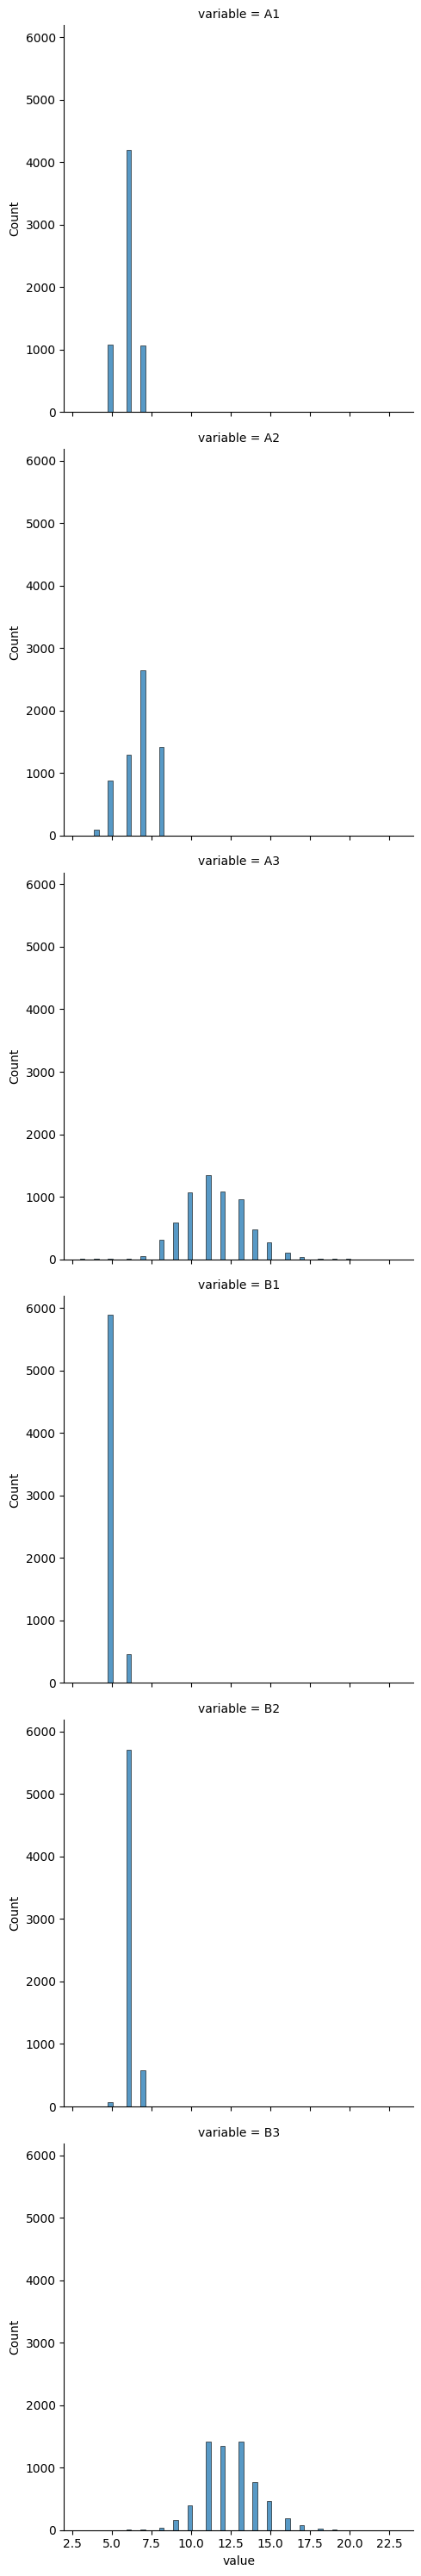

In [6]:
sns.displot(net_tcr_data_positives.filter(regex=r'[A-B]\d').map(len).melt(), row='variable', x='value')

In [7]:
net_tcr_data_positives.filter(regex=r'[A-B][1-3]').map(len).max()

A1     7
A2     8
A3    22
B1     6
B2     7
B3    23
dtype: int64

### Peptides

In [8]:
net_tcr_data_positives['peptide'].unique()

array(['RFPLTFGWCF', 'GILGFVFTL', 'KLGGALQAK', 'DATYQRTRALVR', 'RAKFKQLL',
       'ELAGIGILTV', 'GLCTLVAML', 'AVFDRKSDAK', 'SPRWYFYYL', 'ATDALMTGF',
       'IVTDFSVIK', 'SLFNTVATLY', 'HPVTKYIM', 'YLQPRTFLL', 'RLPGVLPRA',
       'FEDLRLLSF', 'CINGVCWTV', 'KSKRTPMGF', 'FEDLRVLSF', 'GPRLGVRAT',
       'NLVPMVATV', 'VLFGLGFAI', 'LLWNGPMAV', 'RPPIFIRRL', 'CTELKLSDY',
       'RLRAEAQVK'], dtype=object)

In [9]:
net_tcr_data_positives['peptide'].value_counts()

peptide
GILGFVFTL       1125
RAKFKQLL         934
KLGGALQAK        902
AVFDRKSDAK       716
ELAGIGILTV       426
NLVPMVATV        330
IVTDFSVIK        308
LLWNGPMAV        229
CINGVCWTV        226
GLCTLVAML        212
SPRWYFYYL        149
ATDALMTGF        103
DATYQRTRALVR      93
KSKRTPMGF         89
YLQPRTFLL         62
HPVTKYIM          53
RFPLTFGWCF        51
GPRLGVRAT         48
CTELKLSDY         48
RLRAEAQVK         47
RLPGVLPRA         43
SLFNTVATLY        38
RPPIFIRRL         36
FEDLRLLSF         31
VLFGLGFAI         31
FEDLRVLSF         23
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

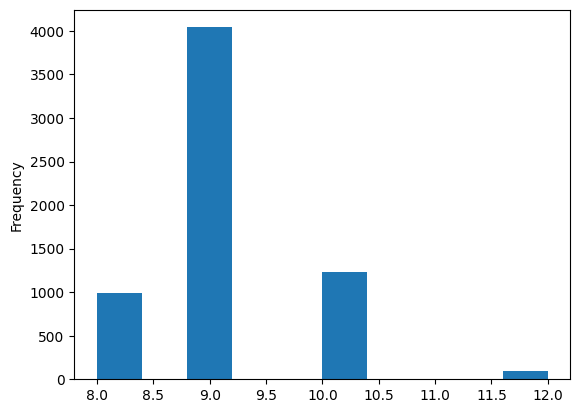

In [10]:
net_tcr_data_positives['peptide'].str.len().plot.hist()

In [11]:
net_tcr_data_positives['peptide'].str.len().max()

12

### MHC Alleles

<Axes: xlabel='allele'>

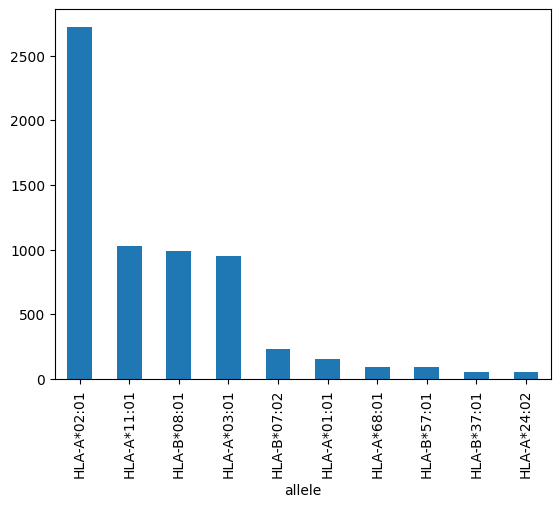

In [12]:
net_tcr_data_positives['allele'].value_counts().plot.bar()

### Relationships between TCRs, peptides, and MHCs

In [13]:
net_tcr_data_positives.value_counts(['peptide', 'allele'])

peptide       allele     
GILGFVFTL     HLA-A*02:01    1125
RAKFKQLL      HLA-B*08:01     934
KLGGALQAK     HLA-A*03:01     902
AVFDRKSDAK    HLA-A*11:01     716
ELAGIGILTV    HLA-A*02:01     426
NLVPMVATV     HLA-A*02:01     330
IVTDFSVIK     HLA-A*11:01     308
LLWNGPMAV     HLA-A*02:01     229
CINGVCWTV     HLA-A*02:01     226
GLCTLVAML     HLA-A*02:01     212
SPRWYFYYL     HLA-B*07:02     149
ATDALMTGF     HLA-A*01:01     103
DATYQRTRALVR  HLA-A*68:01      93
KSKRTPMGF     HLA-B*57:01      89
YLQPRTFLL     HLA-A*02:01      62
HPVTKYIM      HLA-B*08:01      53
RFPLTFGWCF    HLA-A*24:02      51
GPRLGVRAT     HLA-B*07:02      48
CTELKLSDY     HLA-A*01:01      48
RLRAEAQVK     HLA-A*03:01      47
RLPGVLPRA     HLA-A*02:01      43
SLFNTVATLY    HLA-A*02:01      38
RPPIFIRRL     HLA-B*07:02      36
FEDLRLLSF     HLA-B*37:01      31
VLFGLGFAI     HLA-A*02:01      31
FEDLRVLSF     HLA-B*37:01      23
Name: count, dtype: int64

There are no peptides shared between MHC alleles...

In [14]:
net_tcr_data_positives.value_counts(['tcr', 'pmhc']).describe()

count    6353.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

In [15]:
graph = nx.Graph()

graph.add_nodes_from([(tcr, {'color': 'tab:blue'}) for tcr in net_tcr_data_positives['tcr'].unique()])
graph.add_nodes_from([(pmhc, {'color': 'tab:orange'}) for pmhc in net_tcr_data_positives['pmhc'].unique()])

graph.add_edges_from(net_tcr_data_positives[['tcr', 'pmhc']].apply(tuple, axis=1).tolist())

print(graph)

Graph with 6379 nodes and 6353 edges


/ceph/project/koohylab/bmcmaste/miniconda3/envs/tcr-antigen-prediction/lib/python3.11/site-packages/pygraphviz/agraph.py:1403: RuntimeWarning: Warning: tab is not a known color.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


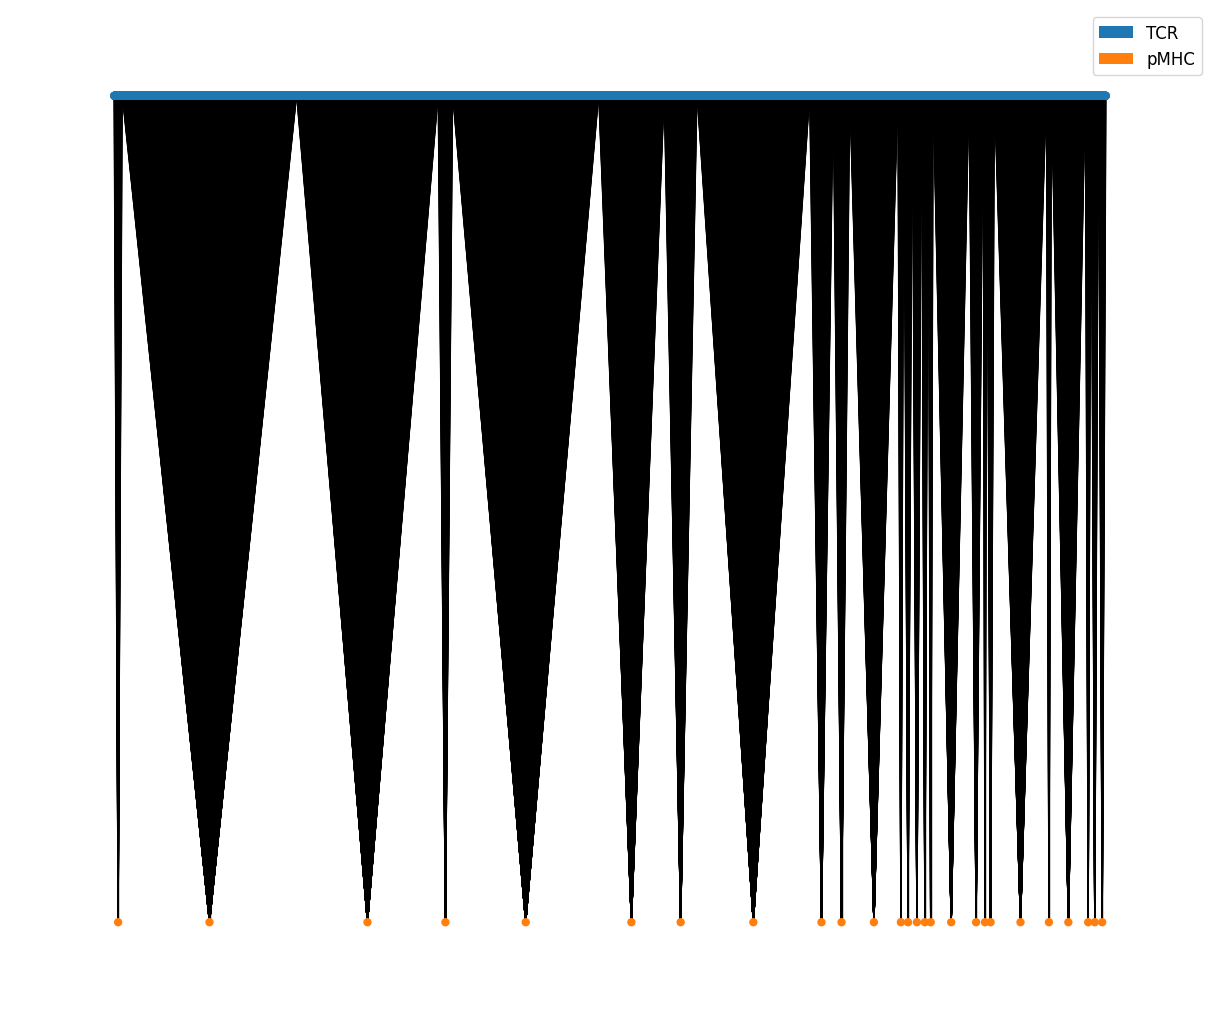

In [16]:
plt.figure(figsize=(12, 10))

nx.draw(
    graph,
    node_size=25,
    node_color=[graph.nodes[node]['color'] for node in graph.nodes()],
    pos=nx.drawing.nx_agraph.graphviz_layout(graph, prog='dot', args='-Granksep=5 -Gnodesep=0.8'),
)
legend_elements = [
    Patch(facecolor='tab:blue', label='TCR'),
    Patch(facecolor='tab:orange', label='pMHC'),
]


plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.show()

There is also a many-to-1 relationship between TCRs and pMHCs in this dataset...

## Adding MHC Pseudo sequence information

In [17]:
hla_sequences = [pd.read_json(path, orient='index') for path in glob.glob('data/external/hla_sequences/*.json')]
hla_sequences = pd.concat(hla_sequences)

hla_sequences

,alleles,canonical_allele,canonical_sequence,gdomain_sequence,pocket_pseudosequence,sequences
hla_b_07_02,"[{'gene_allele_name': 'HLA-B*07:02:01:01', 'id...","{'gene_allele_name': 'HLA-B*07:02:01:01', 'id'...",GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,YYSEYRNIYAQTDESNLYLSYDYYTWAERAYEWY,[GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPRE...
hla_b_07_03,"[{'gene_allele_name': 'HLA-B*07:03', 'id': 'HL...","{'gene_allele_name': 'HLA-B*07:03', 'id': 'HLA...",GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,YYSEYRNIYTNTDESNLYLSYDYYTWAERAYEWY,[GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPRE...
hla_b_07_04,"[{'gene_allele_name': 'HLA-B*07:04:01', 'id': ...","{'gene_allele_name': 'HLA-B*07:04:01', 'id': '...",GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,YYSEYRNIYAQTDESNLYLSYDYYTWAEDAYEWY,[GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPRE...
hla_b_07_05,"[{'gene_allele_name': 'HLA-B*07:05:01:01', 'id...","{'gene_allele_name': 'HLA-B*07:05:01:01', 'id'...",GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,YYSEYRNIYAQTDESNLYLSYNYYTWAERAYEWY,[GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPRE...
hla_b_07_06,"[{'gene_allele_name': 'HLA-B*07:06:01:01', 'id...","{'gene_allele_name': 'HLA-B*07:06:01:01', 'id'...",GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPREE...,YYSEYRNIYAQTDESNLYLSYNYYTWAERAYEWY,[GSHSMRYFYTSVSRPGRGEPRFISVGYVDDTQFVRFDSDAASPRE...
...,...,...,...,...,...,...
h2_kb,"[{'gene_allele_name': 'H2-Kb', 'id': 'P01901',...","{'gene_allele_name': 'H2-Kb', 'id': 'P01901', ...",GPHSLRYFVTAVSRPGLGEPRYMEVGYVDDTEFVRFDSDAENPRYE...,GPHSLRYFVTAVSRPGLGEPRYMEVGYVDDTEFVRFDSDAENPRYE...,YVEYYREKAGNSFVDTLYIVSQYYTWAELAYTWY,[GPHSLRYFVTAVSRPGLGEPRYMEVGYVDDTEFVRFDSDAENPRY...
h2_kd,"[{'gene_allele_name': 'H2-Kd', 'id': 'P01902',...","{'gene_allele_name': 'H2-Kd', 'id': 'P01902', ...",GPHSLRYFVTAVSRPGLGEPRFIAVGYVDDTQFVRFDSDADNPRFE...,GPHSLRYFVTAVSRPGLGEPRFIAVGYVDDTQFVRFDSDADNPRFE...,YVAFYEQRASDWFVSTAYFRFQFYTWADYAYEWY,[GPHSLRYFVTAVSRPGLGEPRFIAVGYVDDTQFVRFDSDADNPRF...
h2_kk,"[{'gene_allele_name': 'H2-Kk', 'id': 'P04223',...","{'gene_allele_name': 'H2-Kk', 'id': 'P04223', ...",GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTQFVRFDSDAENPRYE...,GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTQFVRFDSDAENPRYE...,YHSYYRNIAGNIFVNTAYFRYEYYTWADDAYTWY,[GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTQFVRFDSDAENPRY...
h2_kw28,"[{'gene_allele_name': 'H2-Kw28', 'id': 'P03991...","{'gene_allele_name': 'H2-Kw28', 'id': 'P03991'...",GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTEFVRFDSDAENPRYE...,GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTEFVRFDSDAENPRYE...,YHSYYRNIADNSSVDTLYIRYEVYTWAARAYAWH,[GPHSLRYFHTAVSRPGLGKPRFISVGYVDDTEFVRFDSDAENPRY...


In [18]:
def mhc_code_to_slug(code: str) -> str:
    """Convert MHC allele codes into slugs.

    >>> mhc_code_to_slug('HLA-A*02:01:59')
    'hla_a_02_01_59'

    """
    slug = code.lower()
    slug = re.sub(r'[*:-]', '_', slug)

    return slug


net_tcr_data['mhc_slug'] = net_tcr_data['allele'].map(mhc_code_to_slug)

In [19]:
net_tcr_data['mhc_sequence'] = net_tcr_data.merge(
    hla_sequences,
    how='left',
    left_on='mhc_slug',
    right_index=True,
)['canonical_sequence']

In [20]:
with open('data/interim/mhc_pseudo_seq_imgt_positions.json', 'r') as fh:
    mhc_pseudo_seq_imgt_positions = json.load(fh)

mhc_pseudo_seq_imgt_positions

{'alpha': ['62',
  '63',
  '65',
  '66',
  '68',
  '69',
  '70',
  '72',
  '73',
  '75',
  '76',
  '79'],
 'beta': ['58',
  '61A',
  '62',
  '63',
  '65',
  '66',
  '67',
  '69',
  '70',
  '72',
  '72A',
  '73',
  '76',
  '77']}

In [21]:
def get_pseudo_sequence(mhc_sequence: str) -> list[str]:
    numbering, _ = anarci.number(mhc_sequence)

    mhc_pseudo_seq = []

    for helix in mhc_pseudo_seq_imgt_positions:
        for resi in mhc_pseudo_seq_imgt_positions[helix]:
            imgt_seq_id = (
                int(''.join([char for char in resi if char.isnumeric()]))
                if helix == 'alpha'
                else int(''.join([char for char in '10' + resi if char.isnumeric()]))
            )
            imgt_insert_code = ''.join([char for char in resi if not char.isnumeric()])
            imgt_insert_code = imgt_insert_code if imgt_insert_code else ' '

            for (seq_id, insert_code), res_olc in numbering:
                if seq_id == imgt_seq_id and insert_code == imgt_insert_code:
                    mhc_pseudo_seq.append(res_olc)
                    break

            else:
                mhc_pseudo_seq.append('-')

    return mhc_pseudo_seq

In [22]:
net_tcr_data['mhc_pseudo_sequence'] = net_tcr_data['mhc_sequence'].map(get_pseudo_sequence)

## Processing data

Here, we process the data by centre padding and one-hot-encoding the sequences.

In [23]:
net_tcr_data[[col + '_list' for col in net_tcr_data.filter(regex=r'^([A-B][1-3]|peptide)$').columns]] = (
    net_tcr_data.filter(regex=r'^([A-B][1-3]|peptide)$').map(list)
)

In [24]:
def centre_pad(sequence: list[str], pad_length: int) -> list[str]:
    sequence_length = len(sequence)

    if (pad_length % 2) == (sequence_length % 2):
        pad_per_side = (pad_length - sequence_length) // 2
        pad_right_side = pad_per_side
        pad_left_side = pad_per_side

    else:
        pad_right_side = (pad_length - sequence_length) // 2
        pad_left_side = pad_right_side + 1

    return (['-'] * pad_left_side) + sequence + (['-'] * pad_right_side)

In [25]:
net_tcr_data['A1_pad'] = net_tcr_data['A1_list'].apply(centre_pad, pad_length=8)
net_tcr_data['A2_pad'] = net_tcr_data['A2_list'].apply(centre_pad, pad_length=8)
net_tcr_data['A3_pad'] = net_tcr_data['A3_list'].apply(centre_pad, pad_length=24)

net_tcr_data['B1_pad'] = net_tcr_data['B1_list'].apply(centre_pad, pad_length=8)
net_tcr_data['B2_pad'] = net_tcr_data['B2_list'].apply(centre_pad, pad_length=8)
net_tcr_data['B3_pad'] = net_tcr_data['B3_list'].apply(centre_pad, pad_length=24)

net_tcr_data['peptide_pad'] = net_tcr_data['peptide_list'].apply(centre_pad, pad_length=12)

In [26]:
PROTEIN_LETTERS = sorted(IUPACData.protein_letters_3to1.values())

In [27]:
one_hot_mapping = {}

zero_arr = np.zeros(len(PROTEIN_LETTERS), dtype=int)

for idx, olc in enumerate(PROTEIN_LETTERS):
    encoding = zero_arr.copy()
    encoding[idx] = 1
    one_hot_mapping[olc] = encoding

one_hot_mapping['-'] = zero_arr.copy()
one_hot_mapping

{'A': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'C': array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'D': array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'E': array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'F': array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'G': array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'H': array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'I': array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'K': array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'L': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'M': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'N': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
 'P': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]),
 'Q': array([0, 0, 0, 0, 

In [28]:
encoded_data = net_tcr_data.filter(regex='_pad$|mhc_pseudo_sequence').map(
    lambda seq: np.array([one_hot_mapping[olc] for olc in seq]),
)
encoded_data['label'] = net_tcr_data['binder']

In [29]:
peptide_numbers = net_tcr_data['peptide'].map(
    {peptide: num for num, peptide in enumerate(net_tcr_data['peptide'].unique(), 1)},
)

In [30]:
encoded_data['peptide_number'] = peptide_numbers

In [31]:
random.seed(123)


def create_even_folds(counts: list[tuple[int, int]], num_folds: int = 5) -> tuple[list[int]]:
    total_sum = sum([size for _, size in counts])
    target_sum = total_sum / num_folds

    groups = [[] for _ in range(num_folds)]
    sum_groups = [0] * num_folds

    random.shuffle(counts)

    for number, size in counts:
        # Find the group with the smallest current sum and add the number
        min_sum_index = min(range(num_folds), key=lambda i: sum_groups[i])

        if sum_groups[min_sum_index] + size <= target_sum:
            groups[min_sum_index].append(number)
            sum_groups[min_sum_index] += size

        else:
            # If adding the number exceeds the target sum, add to the next group
            for i in range(num_folds):
                if i != min_sum_index and sum_groups[i] + size <= target_sum:
                    groups[i].append(number)
                    sum_groups[i] += size
                    break
            else:  # If it doesn't fit anywhere, add it to the original trial
                groups[min_sum_index].append(number)
                sum_groups[min_sum_index] += size

    return tuple(groups)


peptide_counts = list(
    zip(
        encoded_data['peptide_number'].value_counts().index,
        encoded_data['peptide_number'].value_counts(),
        strict=True,
    )
)

encoded_data['fold'] = encoded_data['peptide_number'].map(
    {
        peptide_number: fold
        for fold, peptide_numbers in enumerate(create_even_folds(peptide_counts), 1)
        for peptide_number in peptide_numbers
    }
)

In [32]:
cdr_name_map = {'A1': 'cdr_1a', 'A2': 'cdr_2a', 'A3': 'cdr_3a', 'B1': 'cdr_1b', 'B2': 'cdr_2b', 'B3': 'cdr_3b'}

encoded_data.columns = [col.replace('_pad', '') for col in encoded_data.columns]
encoded_data.columns = [cdr_name_map.get(col, col) for col in encoded_data.columns]

In [33]:
encoded_data

,mhc_pseudo_sequence,cdr_1a,cdr_2a,cdr_3a,cdr_1b,cdr_2b,cdr_3b,peptide,label,peptide_number,fold
index,,,,,,,,,,,
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,1,2
1,"[[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,2,5
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,3,2
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,3,2
4,"[[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,4,3
...,...,...,...,...,...,...,...,...,...,...,...
37716,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,6,1
37717,"[[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,14,5
37718,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0,3,2


## Outputting data

In [34]:
with h5py.File('data/processed/nettcr.h5', 'w') as fh:
    for col in encoded_data.columns:
        fh[col] = np.array(encoded_data[col].tolist())